In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/starter_data.csv', parse_dates=['date'])
df.head()

,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


In [2]:
category_dummies = pd.get_dummies(df['category'], prefix='category')
df = pd.concat([df, category_dummies], axis=1)
df.head()

,category,value,date,category_A,category_B,category_C
0,A,10,2025-08-01,True,False,False
1,B,15,2025-08-02,False,True,False
2,A,12,2025-08-03,True,False,False
3,B,18,2025-08-04,False,True,False
4,C,25,2025-08-05,False,False,True


In [3]:
df[['value', 'category_A', 'category_B']].corr()

,value,category_A,category_B
value,1.000000,-0.711228,-0.180735
category_A,-0.711228,1.000000,-0.534522
category_B,-0.180735,-0.534522,1.000000


In [4]:
df['value_zscore'] = (df['value'] - df['value'].mean()) / df['value'].std()
df[['value', 'value_zscore']].head()

,value,value_zscore
0,10,-1.029579
1,15,-0.352224
2,12,-0.758637
3,18,0.054188
4,25,1.002485


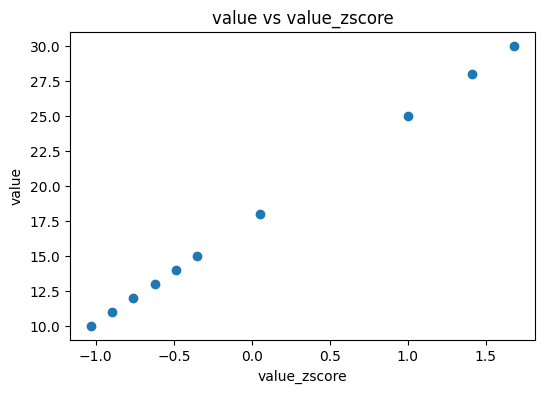

In [5]:
plt.figure(figsize=(6, 4))
plt.scatter(df['value_zscore'], df['value'])
plt.xlabel('value_zscore')
plt.ylabel('value')
plt.title('value vs value_zscore')
plt.show()

In [6]:
df = df.sort_values('date')
df['value_rolling_mean'] = df['value'].rolling(window=3, min_periods=1).mean()
df[['date', 'value', 'value_rolling_mean']].head(6)

,date,value,value_rolling_mean
0,2025-08-01,10,10.000000
1,2025-08-02,15,12.500000
2,2025-08-03,12,12.333333
3,2025-08-04,18,15.000000
4,2025-08-05,25,18.333333
5,2025-08-06,30,24.333333


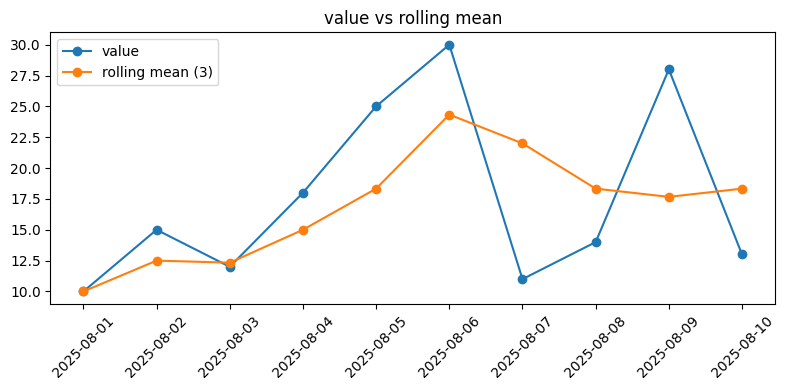

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(df['date'], df['value'], label='value', marker='o')
plt.plot(df['date'], df['value_rolling_mean'], label='rolling mean (3)', marker='o')
plt.legend()
plt.title('value vs rolling mean')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
feature_cols = ['category_A', 'category_B', 'value_zscore', 'value_rolling_mean']
existing = [c for c in feature_cols if c in df.columns]
df[existing + ['value']].corr()['value']

category_A           -0.711228
category_B           -0.180735
value_zscore          1.000000
value_rolling_mean    0.519244
value                 1.000000
Name: value, dtype: float64

In [ ]:
import sys
sys.path.append('../src')
from features import encode_category_onehot, add_zscore, add_rolling_mean

df_check = pd.read_csv('../data/raw/starter_data.csv', parse_dates=['date'])
df_check = encode_category_onehot(df_check)
df_check = add_zscore(df_check)
df_check = add_rolling_mean(df_check)
df_check.head()